In [1]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.optimize import nnls
import scipy.linalg
import matplotlib.pyplot as plt
from iminuit import Minuit
from scipy.optimize import nnls, minimize

from pyPAS.core.lt import MultiGaussianRF, PASLifetime, TimeResolution
from pyPAS.lifetime.generator import generate_random_lt_spectrum, generate_analytical_lt_spectrum
from pyPAS.lifetime.model import LifetimeModel
from pyspectrum import Spectrum
np.random.seed(42)

# system parmeters 

In [2]:
irf_sigma = np.array([0.099, 0.250, 0.174])
irf_amp = np.array([418.48, 5.43, 34.80])
irf_t0 = np.array([-0.148, -0.146, -0.087]) - (np.array([-0.148, -0.146, -0.087])*irf_amp/irf_amp.sum()).sum()
IRF = MultiGaussianRF(irf_sigma, irf_amp,irf_t0)

In [3]:
# read_measurements 

In [4]:
data = np.load('F:/Data/lifetime/epoxy_lftm_100k.npz')

centers = data['centers']
idx_min = np.where(centers>-5)[0][0]
#idx_max = np.where(centers>40)[0][0]

centers = centers[idx_min:-1000]+ 0.08
counts = data['counts_sum'][idx_min:-1000]
#counts -= counts[-500:].mean()

t_calib = np.poly1d(np.polyfit(np.arange(len(counts)), centers, deg=1))
lifetime_data = Spectrum(counts=counts, channels=np.arange(len(counts)), energy_calibration_poly=t_calib)

In [5]:
random_spectrum = PASLifetime(lifetime=lifetime_data, resolution=IRF)

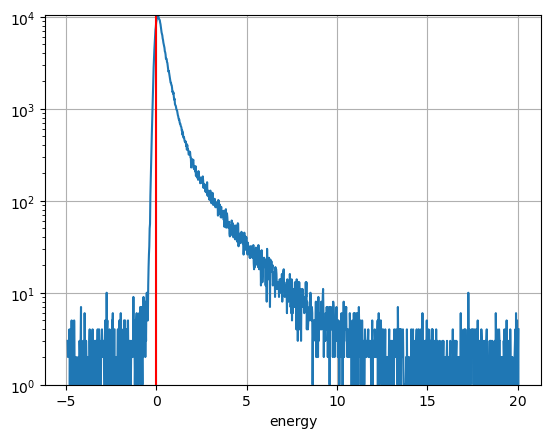

In [6]:
random_spectrum.lifetime.plot(yscale='log')
#plt.xlim([-5, centers[-1]])
plt.ylim([1, random_spectrum.lifetime.max()])
plt.axvline(0, color='red')
plt.grid()

# Inversion

In [7]:
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix
from matplotlib.colors import LogNorm
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.tikhonov import TikhonovRegularization
from pyPAS.optimizer.lifetime.inversion.maximum_entropy import MaximalEntropyInversion

In [8]:
dτ = 1e-2
τ_grid = np.arange(dτ, 5, dτ)

time_grid = random_spectrum.lifetime.energy.values
dt = (random_spectrum.lifetime.energy[1]-random_spectrum.lifetime.energy[0]).item()

In [9]:
n_tau =len(τ_grid)
np.trapz(np.ones(n_tau) / np.trapz(np.ones(n_tau) , τ_grid) , τ_grid)

0.9999999999999998

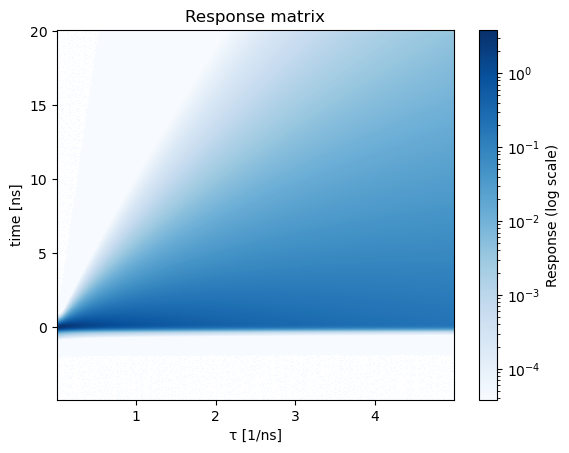

In [10]:
RM = _response_matrix(τ_grid, time_grid, IRF)
vmax = RM.max()
vmin = vmax / 1e5   # 5 orders of magnitude

plt.imshow(RM,
           cmap='Blues',
           origin='lower',
           extent=[τ_grid.min(), τ_grid.max(),
                   time_grid.min(), time_grid.max(),
                   ],
           aspect='auto',
           norm=LogNorm(vmin=vmin, vmax=vmax))

plt.colorbar(label='Response (log scale)')
plt.title('Response matrix')
plt.ylabel('time [ns]')
plt.xlabel('τ [1/ns]')
plt.show()

In [ ]:
tinvert = TikhonovRegularization(random_spectrum.lifetime.energy.values, τ_grid)
q, res = tinvert.invert(random_spectrum, initial_alpha=1e-5, bg_est=random_spectrum.lifetime.counts[-350:].mean())

In [ ]:
# the resulted optimization gives gives integral of 1 as expected
np.trapz(q, τ_grid), res

In [ ]:
plt.plot(τ_grid, q, label='tikhonov')
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")
plt.xlim([0,5])
plt.legend()

In [ ]:
tikhonov_result_model = LifetimeModel('', τ_grid, q)
tikhonov_lifetime = generate_analytical_lt_spectrum(time_grid,
                                                    tikhonov_result_model,
                                                    resolution=IRF,
                                                    background_fraction=0.0)
norm = (random_spectrum.lifetime-random_spectrum.lifetime.counts[-350:].mean()).integrate("energy").item()
tikhonov_lifetime.lifetime.counts *= norm
tikhonov_lifetime.lifetime.counts += random_spectrum.lifetime.counts[-350:].mean()
(random_spectrum.lifetime).plot(yscale='log', label='measured')
tikhonov_lifetime.lifetime.plot(label='tikhonov')

plt.grid(which="both")

plt.ylim([random_spectrum.lifetime.counts[:200].mean()/2, random_spectrum.lifetime.max()])

plt.xlim([-5, 20])
plt.axvline(time_grid[np.argmax(tikhonov_lifetime.lifetime.counts)])
plt.axvline(time_grid[np.argmax(random_spectrum.lifetime.counts)], color='red')

plt.legend()
plt.show()

Melt

In [ ]:
melt = MaximalEntropyInversion(random_spectrum.lifetime.energy.values, τ_grid)

In [ ]:
a1, melt_q1 = melt.invert(pals=random_spectrum, maxiter=400, noise_level = 1e-3, bg_est=random_spectrum.lifetime.counts[-200:].mean())

In [ ]:
a2, melt_q2 = melt.invert(pals=random_spectrum, maxiter=400, noise_level = 1e-6, bg_est=random_spectrum.lifetime.counts[-200:].mean())

In [ ]:
a2, a1

In [ ]:
np.trapz(melt_q1, τ_grid)

In [ ]:
np.trapz((RM*dτ) @ (melt_q1) , random_spectrum.lifetime.energy)

In [ ]:
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.plot(τ_grid, melt_q1/np.trapz(melt_q1,τ_grid), label='MELT1')
plt.plot(τ_grid, melt_q2/np.trapz(melt_q2,τ_grid), label='MELT2')

plt.yscale("log")
#plt.xscale("log")

plt.ylim([1e-6, np.max([melt_q1.max()/np.trapz(melt_q1,τ_grid),melt_q2.max()/np.trapz(melt_q2,τ_grid),q.max()/np.trapz(q,τ_grid)])])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()
plt.show()

In [ ]:
melt_q2.max()

In [ ]:
np.trapz(melt_q2, x=τ_grid)

In [ ]:
melt_result_model1 = LifetimeModel('', τ_grid, melt_q1/np.trapz(melt_q1,τ_grid))
melt_result_model2 = LifetimeModel('', τ_grid, melt_q2/np.trapz(melt_q2,τ_grid))

melt_lifetime1 = generate_analytical_lt_spectrum(time_grid,
                                                    melt_result_model1,
                                                    resolution=IRF,
                                                    background_fraction=0.00)
melt_lifetime2 = generate_analytical_lt_spectrum(time_grid,
                                                    melt_result_model2,
                                                    resolution=IRF,
                                                    background_fraction=0.00)
norm = (random_spectrum.lifetime-random_spectrum.lifetime.counts[-350:].mean()).integrate('energy').item()
melt_lifetime1.lifetime.counts *= norm
melt_lifetime2.lifetime.counts *= norm
melt_lifetime1.lifetime.counts += random_spectrum.lifetime.counts[-200:].mean()
melt_lifetime2.lifetime.counts += random_spectrum.lifetime.counts[-200:].mean()
(random_spectrum.lifetime).plot(yscale='log', label='measured')
tikhonov_lifetime.lifetime.plot(label='tikhonov')
melt_lifetime1.lifetime.plot(label='melt1')
melt_lifetime2.lifetime.plot(label='melt2')
plt.grid(which="both")

plt.ylim([1e-5, random_spectrum.lifetime.max()])
plt.xlim([-2, 15])


plt.legend()

In [ ]:
(((random_spectrum.lifetime.counts - melt_lifetime2.lifetime.counts)/(1+random_spectrum.lifetime.counts)).sum())/len(random_spectrum.lifetime.counts)

In [ ]:
(((random_spectrum.lifetime.counts - melt_lifetime1.lifetime.counts)/(1+random_spectrum.lifetime.counts)).sum())/len(random_spectrum.lifetime.counts)

In [ ]:
eg = 170
em = 511
t = np.pi

eg - eg/(1+eg/em*(1-np.cos(t)))

In [ ]:
import numpy as np
import xarray as xr
from scipy.optimize import minimize, nnls
from pyPAS.core.lt import PASLifetime
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix, _svd_truncate

class MELTInversion(LifetimeInvert):
    """
    Inverts a positron lifetime spectrum into a lifetime distribution q(τ)
    using the Maximum Entropy method (MELT).

    The inversion maximizes:
        S(q) - α · χ²(q)

    where S(q) = -Σ qᵢ log(qᵢ/mᵢ) is the relative entropy with respect to
    a default model m, and χ² measures fit quality. α is determined
    automatically within the Bayesian framework.

    The response matrix is first cleaned via SVD truncation — singular values
    below the noise threshold are discarded, removing noise-dominated directions
    before the MaxEnt optimization.
    """


    def _entropy(self, q: np.ndarray, prior_model: np.ndarray) -> float:
        """
        Relative Shannon entropy of q with respect to default model m.

            S(q) = -Σ qᵢ log(qᵢ / mᵢ)

        Parameters
        ----------
        q : np.ndarray
            Current lifetime distribution (must be positive).
        prior_model : np.ndarray
            Prior default model over tau grid. Flat if no prior knowledge.

        Returns
        -------
        float
            Entropy value (positive when q ≈ m).
        """
        q_safe = np.clip(q, 1e-30, None)
        return -np.sum(q_safe * np.log(q_safe / prior_model))

    def _chi_sq(self,
                q: np.ndarray,
                U: np.ndarray,
                s: np.ndarray,
                Vt: np.ndarray,
                normlized_pals: np.ndarray,
                normlized_pals_err: np.ndarray) -> float:
        """
        Chi-squared residual in the truncated SVD space.

        Parameters
        ----------
        q : np.ndarray
            Current lifetime distribution.
        U, s, Vt : np.ndarray
            Truncated SVD components of the scaled response matrix.
        normlized_pals : np.ndarray
            Normalized measured spectrum.
        normlized_pals_err : np.ndarray
            Poisson uncertainty on normalized spectrum.

        Returns
        -------
        float
            Chi-squared value.
        """
        lifetime_q = U @ (s * (Vt @ q))  # = response_clean @ q
        mask = normlized_pals > 0
        residuals = (normlized_pals[mask] - lifetime_q[mask]) ** 2
        return np.sum(residuals / normlized_pals_err[mask] ** 2)

    def _melt_objective(self,
                        log_q: np.ndarray,
                        alpha: float,
                        U: np.ndarray,
                        s: np.ndarray,
                        Vt: np.ndarray,
                        normlized_pals: np.ndarray,
                        normlized_pals_err: np.ndarray,
                        default_model: np.ndarray) -> float:
        """
        MELT objective function: α·χ²(q) - S(q), minimized over log(q).

        Parameterized in log space to enforce q > 0 without constraints.

        Parameters
        ----------
        log_q : np.ndarray
            Log of the lifetime distribution (optimization variable).
        alpha : float
            Entropy weight — balances fit fidelity against entropy.
        U, s, Vt : np.ndarray
            Truncated SVD components.
        normlized_pals : np.ndarray
            Normalized measured spectrum.
        normlized_pals_err : np.ndarray
            Poisson uncertainty.
        default_model : np.ndarray
            Prior default model for entropy calculation.

        Returns
        -------
        float
            Objective value.
        """
        q = np.exp(log_q)
        chi2 = self._chi_sq(q, U, s, Vt, normlized_pals, normlized_pals_err)
        entropy = self._entropy(q, default_model)
        return alpha * chi2 - entropy

    def _find_alpha(self,
                    log_q: np.ndarray,
                    U: np.ndarray,
                    s: np.ndarray,
                    Vt: np.ndarray,
                    normlized_pals: np.ndarray,
                    normlized_pals_err: np.ndarray,
                    default_model: np.ndarray,
                    n_good: int,
                    alpha_bounds: tuple,
                    ftol: float) -> float:
        """
        Determine optimal alpha by matching χ² ≈ n_good (number of
        retained singular values) — the Bayesian evidence criterion.

        Parameters
        ----------
        log_q : np.ndarray
            Current log distribution (warm start).
        n_good : int
            Number of retained singular values — target for χ².
        alpha_bounds : tuple
            (min, max) bounds for alpha search.
        ftol : float
            Convergence tolerance.

        Returns
        -------
        float
            Optimal alpha.
        """
        def chi_sq_gap(log_alpha):
            alpha = float(np.exp(log_alpha[0]))
            res = minimize(
                self._melt_objective,
                x0=log_q,
                args=(alpha, U, s, Vt, normlized_pals, normlized_pals_err, default_model),
                method="L-BFGS-B",
                options={"ftol": ftol, "maxiter":100}
            )
            q = np.exp(res.x)
            chi2 = self._chi_sq(q, U, s, Vt, normlized_pals, normlized_pals_err)
            return (chi2 - n_good) ** 2  # drive χ² → n_good

        res = minimize(
            chi_sq_gap,
            x0=[np.log(1e-3)],
            bounds=[(np.log(alpha_bounds[0]), np.log(alpha_bounds[1]))],
            method="Powell",
            options={"ftol": ftol, "maxiter":100},
            
        )
        return float(np.exp(res.x[0]))

    def invert(self,
               pals: PASLifetime,
               maxiter=None,
               noise_level=1e-10,
               initial_alpha=1e-3,
               alpha_bounds=(1e-10, 1e2),
               prior_model=None,
               minimization_ftol=1e-6) -> tuple[np.ndarray, object]:
        """
        Invert a lifetime spectrum into a lifetime distribution q(τ) via MELT.

        Parameters
        ----------
        pals : PASLifetime
            Measured lifetime spectrum with resolution function.
        maxiter : int, optional
            Max iterations for inner optimizer. Defaults to 10 * n_tau.
        noise_level : float
            SVD truncation threshold relative to largest singular value.
            Default 1e-3.
        initial_alpha : float
            Starting alpha for Bayesian evidence search. Default 1e-3.
        alpha_bounds : tuple
            (min, max) bounds for alpha. Default (1e-10, 1e2).
        prior_model : np.ndarray, optional
            Prior over tau grid. Defaults to flat (uniform) model.
        minimization_ftol : float
            Convergence tolerance. Default 1e-6.

        Returns
        -------
        q : np.ndarray
            Recovered lifetime distribution over characteristic_time_grid.
        res : OptimizeResult
            Final scipy optimization result.
        """
        if maxiter is None:
            maxiter = 10 * self.characteristic_time_grid.shape[0]

        n_tau = len(self.characteristic_time_grid)
        dtau = self.characteristic_time_grid[1] - self.characteristic_time_grid[0]

        if prior_model is None:
            prior_model = np.ones(n_tau) / (self.characteristic_time_grid[-1] - self.characteristic_time_grid[0])  # flat prior

        # ---- normalize data ----
        counts = pals.lifetime.counts
        norm = pals.lifetime.integrate('energy').item()
        normlized_pals = counts / norm
        normlized_pals_err = np.sqrt(counts) / norm

        # ---- build and clean response matrix ----
        response = _response_matrix(
            self.characteristic_time_grid,
            pals.lifetime.energy.values,
            pals.resolution
        )
        U, s, Vt = _svd_truncate(response * dtau, noise_level)
        n_good = len(s)  # number of retained singular values

        # ---- find optimal alpha ----
        log_q0 = np.log(default_model)
        alpha_opt = self._find_alpha(
            log_q=log_q0,
            U=U, s=s, Vt=Vt,
            normlized_pals=normlized_pals,
            normlized_pals_err=normlized_pals_err,
            default_model=default_model,
            n_good=n_good,
            alpha_bounds=alpha_bounds,
            ftol=minimization_ftol
        )

        # ---- final solution at optimal alpha ----
        res = minimize(
            self._melt_objective,
            x0=log_q0,
            args=(alpha_opt, U, s, Vt, normlized_pals, normlized_pals_err, default_model),
            method="L-BFGS-B",
            options={"ftol": minimization_ftol, "maxiter": maxiter}
        )

        q = np.exp(res.x)
        return q, res